# VertexCBF — double integrator

A minimal end-to-end run of the method: state the problem, generate labels with a
vertex-restricted search, train the neural CBF, then use it.

The CBF is parametrised as $V_\Theta(x) = c(x) - r_\Theta(x)$ with $r_\Theta \ge 0$, so the
learned safe set $\{V_\Theta \ge 0\}$ can never exceed the constraint set $\{c \ge 0\}$.

In [1]:
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D

from vertexcbf import (
    MLP,
    DoubleIntegrator1D,
    Trainer,
    beam_search,
    interval_sdf,
    stratified_sample_by_predicted_cbf,
    validate_cbf,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)
np.random.seed(0)

C_CONSTRAINT = "black"    # c(x) = 0
C_TRUE = "#eb6834"        # analytical safe-set boundary
C_LEARNED = "#2a78d6"     # V_Θ(x) = 0
C_SAFE = "#1baf7a"
C_UNSAFE = "#e34948"
CMAP_V = "RdBu"           # diverging, centred at 0: red = unsafe, blue = safe

print(f"device: {device}")

device: cuda


## 1. Problem

A system is a `ControlAffine` subclass giving the drift $f(x)$ and input matrix $g(x)$ of
$\dot x = f(x) + g(x)u$, plus a state box and a control box. The constraint $c(x)$ is any
differentiable function that is positive on the allowed set.

Here: a 1-D double integrator ($p$ = position, $v$ = velocity, $u$ = acceleration) with
$|p| \le 1$ and $|u| \le 0.5$. It has an analytical answer to check against — a state is
truly safe iff it can still stop before the wall, $|p + v|v| / (2 u_{\max})| \le 1$.

nx=2, nu=1, control vertices: [-0.5, 0.5]


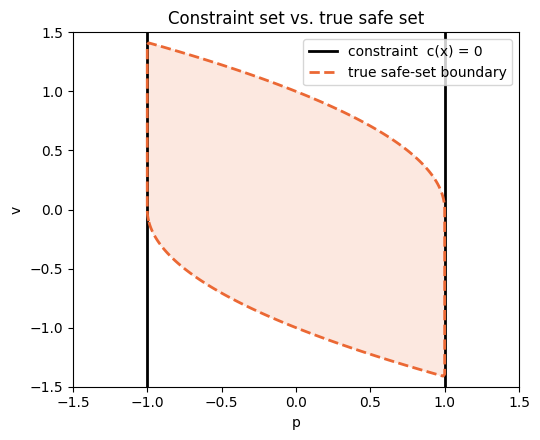

In [2]:
U_MAX = 0.5   # acceleration limit
D = 1.0       # half-width of the allowed position interval

dyn = DoubleIntegrator1D(
    x_min=[-1.5, -1.5], x_max=[1.5, 1.5],
    u_min=[-U_MAX], u_max=[U_MAX],
    device=device,
)
constr_fn = partial(interval_sdf, center=0.0, d=D)   # c(x) = D - |p|

print(f"nx={dyn.nx}, nu={dyn.nu}, control vertices: {dyn.get_control_vertices().flatten().tolist()}")


def true_safe_margin(x: np.ndarray) -> np.ndarray:
    # Positive inside the true (maximal control-invariant) safe set, negative outside.
    p, v = x[..., 0], x[..., 1]
    stop = p + v * np.abs(v) / (2 * U_MAX)      # where it comes to rest under max braking
    return np.minimum.reduce([D - np.abs(p), D - stop, D + stop])


G = dyn.get_uniform_state_grid([200, 200]).cpu().numpy()          # (200, 200, nx)
G_t = torch.as_tensor(G.reshape(-1, dyn.nx), device=device)
constr_on_grid = constr_fn(G_t).reshape(G.shape[:2]).cpu().numpy()
true_on_grid = true_safe_margin(G)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.contourf(G[..., 0], G[..., 1], true_on_grid, levels=[0, 1e9], colors=[C_TRUE], alpha=0.15)
ax.contour(G[..., 0], G[..., 1], constr_on_grid, levels=[0], colors=C_CONSTRAINT, linewidths=2)
ax.contour(G[..., 0], G[..., 1], true_on_grid, levels=[0], colors=C_TRUE, linewidths=2, linestyles="--")
ax.legend(handles=[
    Line2D([], [], color=C_CONSTRAINT, lw=2, label="constraint  c(x) = 0"),
    Line2D([], [], color=C_TRUE, lw=2, ls="--", label="true safe-set boundary"),
], loc="upper right")
ax.set_xlabel("p"); ax.set_ylabel("v"); ax.set_title("Constraint set vs. true safe set")
plt.tight_layout(); plt.show()

## 2. Labels and training

For control-affine dynamics and a box control set the Hamiltonian is attained at a *vertex*
of the box, so labels can be generated by searching over vertex sequences only.
`beam_search` finds, for each initial state in parallel on the GPU, the sequence maximising
$\min_{k \le K} c(x_k)$ along an Euler rollout — the right panel shows a few of those
optimal trajectories, bang-bang by construction.

`Trainer` then minimises $w\,\mathcal{L}_{\text{PDE}} + (1-w)\,\mathcal{L}_{\text{data}}$:
the stationary HJB variational inequality on a grid of collocation states, plus a regression
onto these labels.

1681 labels, 37.7% labelled safe


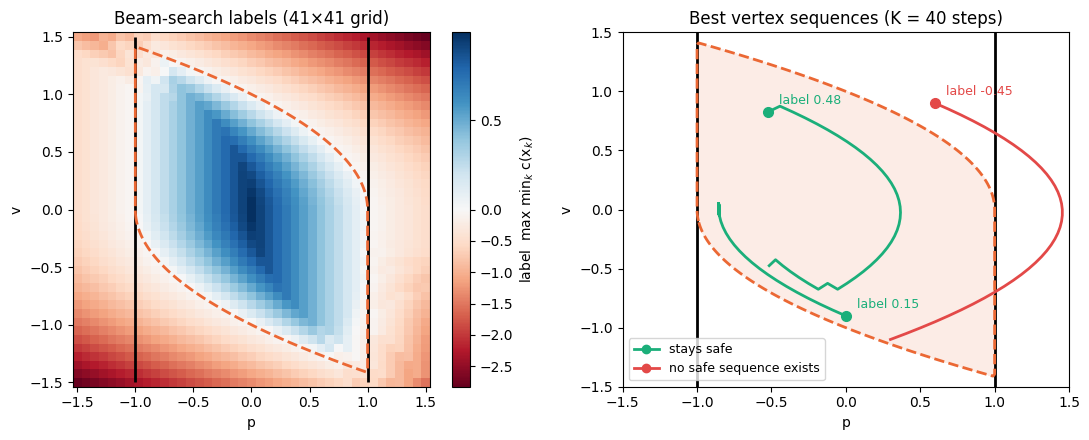

control sequence of the first trajectory (only ±u_max appear):
 [ 0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5 -0.5]


In [3]:
states_d = dyn.get_uniform_state_grid([41, 41]).reshape(-1, dyn.nx)
search = beam_search(dynamics=dyn, x0=states_d, constr_fn=constr_fn,
                     B=1000, K=40, dt=0.1, return_trajs=True)
values_d = search["values"]
print(f"{states_d.shape[0]} labels, {(values_d > 0).float().mean() * 100:.1f}% labelled safe")

grid_d = states_d.reshape(41, 41, dyn.nx).cpu().numpy()
labels_grid = values_d.reshape(41, 41).cpu().numpy()

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
im = ax.pcolormesh(grid_d[..., 0], grid_d[..., 1], labels_grid, cmap=CMAP_V, shading="nearest",
                   norm=TwoSlopeNorm(vmin=labels_grid.min(), vcenter=0.0, vmax=labels_grid.max()))
ax.contour(G[..., 0], G[..., 1], constr_on_grid, levels=[0], colors=C_CONSTRAINT, linewidths=2)
ax.contour(G[..., 0], G[..., 1], true_on_grid, levels=[0], colors=C_TRUE, linewidths=2, linestyles="--")
fig.colorbar(im, ax=ax, label=r"label  max min$_k$ c(x$_k$)")
ax.set_xlabel("p"); ax.set_ylabel("v"); ax.set_title("Beam-search labels (41×41 grid)")

# Best vertex sequence found for three initial states.
probes = [(-0.5, 0.8), (0.0, -0.9), (0.6, 0.9)]
picks = [int(np.argmin(np.linalg.norm(states_d.cpu().numpy() - np.array(p), axis=1))) for p in probes]
trajs = search["state_traj"][picks].cpu().numpy()      # (3, K+1, nx)
ctrls = search["control_traj"][picks].cpu().numpy()    # (3, K, nu)

ax2.contourf(G[..., 0], G[..., 1], true_on_grid, levels=[0, 1e9], colors=[C_TRUE], alpha=0.12)
ax2.contour(G[..., 0], G[..., 1], constr_on_grid, levels=[0], colors=C_CONSTRAINT, linewidths=2)
ax2.contour(G[..., 0], G[..., 1], true_on_grid, levels=[0], colors=C_TRUE, linewidths=2, linestyles="--")
for i, tr in enumerate(trajs):
    v = values_d[picks[i]].item()
    col = C_SAFE if v > 0 else C_UNSAFE
    ax2.plot(tr[:, 0], tr[:, 1], "-", color=col, lw=2)
    ax2.plot(tr[0, 0], tr[0, 1], "o", color=col, ms=7)
    ax2.annotate(f"label {v:.2f}", tr[0], textcoords="offset points", xytext=(8, 6), fontsize=9, color=col)
ax2.set_xlim(dyn.x_min[0].item(), dyn.x_max[0].item()); ax2.set_ylim(dyn.x_min[1].item(), dyn.x_max[1].item())
ax2.set_xlabel("p"); ax2.set_ylabel("v"); ax2.set_title("Best vertex sequences (K = 40 steps)")
ax2.legend(handles=[
    Line2D([], [], color=C_SAFE, lw=2, marker="o", label="stays safe"),
    Line2D([], [], color=C_UNSAFE, lw=2, marker="o", label="no safe sequence exists"),
], loc="lower left", fontsize=9)
plt.tight_layout(); plt.show()

print("control sequence of the first trajectory (only ±u_max appear):\n", ctrls[0, :12, 0])

Epoch [   500/3000]  loss=0.214628  pde=0.196312  data=0.379477
Epoch [  1000/3000]  loss=0.007142  pde=0.005882  data=0.018488
Epoch [  1500/3000]  loss=0.002969  pde=0.001224  data=0.018671
Epoch [  2000/3000]  loss=0.002460  pde=0.000715  data=0.018167
Epoch [  2500/3000]  loss=0.002434  pde=0.000691  data=0.018121
Epoch [  3000/3000]  loss=0.002408  pde=0.000667  data=0.018082


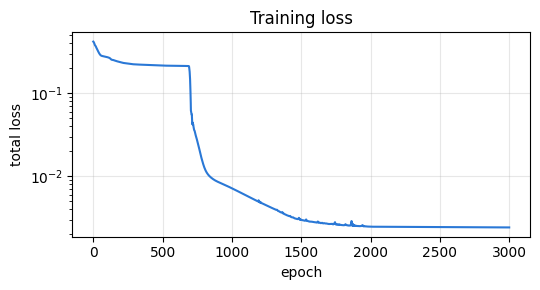

In [4]:
model = MLP(
    layers_config=[(dyn.nx, None)] + [(32, "sin")] * 4 + [(1, ("softplus", {"beta": 10.0}))],
    input_min=dyn.x_min, input_max=dyn.x_max,
    periodic_inputs=dyn.periodic_states,   # angles would be (cos, sin)-encoded here
).to(device)

trainer = Trainer(
    dynamics=dyn, model=model, constr_fn=constr_fn,
    epochs=3000, lr=1e-3, lr_milestones=[2000], lr_gamma=0.1,
    pde_grid_shape=(100, 100),
    pde_weight_mode="fixed", pde_weight=0.9,
    data_states=states_d, data_values=values_d,
    log_every=500,
)
losses = trainer.train()

fig, ax = plt.subplots(figsize=(5.5, 3))
ax.semilogy(losses, color=C_LEARNED, lw=1.5)
ax.set_xlabel("epoch"); ax.set_ylabel("total loss"); ax.set_title("Training loss")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 3. Result

The model returns the residual, so the CBF is always `constr_fn(x) - model(x)`. Below: its
zero-level set against the analytical boundary, and a closed-loop check — `validate_cbf`
rolls out the Hamiltonian-greedy policy $u^*(x) = \arg\max_u \nabla V_\Theta(x)\cdot(f + gu)$
and reports how often a predicted-safe state actually stayed safe.

sign agreement with the analytical safe set: 99.69%
false-safe rate    0.05%   (predicted safe but violated — the safety-critical number)
false-unsafe rate  0.25%   (conservativeness)


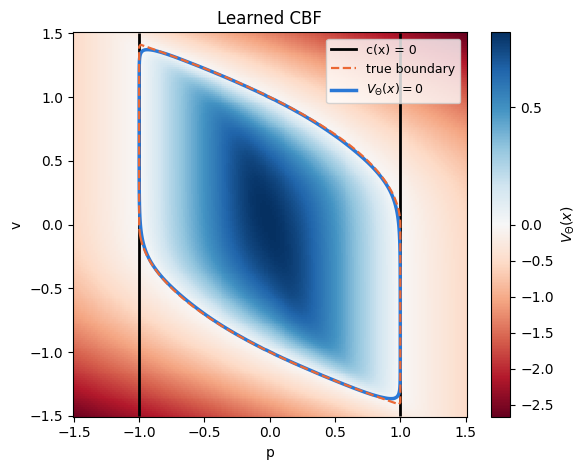

In [5]:
def cbf(x: torch.Tensor) -> torch.Tensor:
    # V_Θ(x) = c(x) - r_Θ(x), for a batch x of shape (N, nx) → (N,)
    return (constr_fn(x) - model(x)).squeeze(-1)


with torch.no_grad():
    V_grid = cbf(G_t).reshape(G.shape[:2]).cpu().numpy()
norm_V = TwoSlopeNorm(vmin=V_grid.min(), vcenter=0.0, vmax=V_grid.max())

print(f"sign agreement with the analytical safe set: {np.mean((V_grid > 0) == (true_on_grid > 0)) * 100:.2f}%")

samples = stratified_sample_by_predicted_cbf(dyn, constr_fn, model, num_per_stratum=2000)
sm = validate_cbf(dyn, samples["states"], constr_fn, model, T=5.0, dt=0.01)["stratified_metrics"]
print(f"false-safe rate   {sm['predicted_safe']['false_safe_rate']:5.2f}%   "
      f"(predicted safe but violated — the safety-critical number)")
print(f"false-unsafe rate {sm['predicted_unsafe']['false_unsafe_rate']:5.2f}%   (conservativeness)")

fig, ax = plt.subplots(figsize=(6, 4.8))
im = ax.pcolormesh(G[..., 0], G[..., 1], V_grid, cmap=CMAP_V, shading="auto", rasterized=True, norm=norm_V)
ax.contour(G[..., 0], G[..., 1], constr_on_grid, levels=[0], colors=C_CONSTRAINT, linewidths=2)
ax.contour(G[..., 0], G[..., 1], V_grid, levels=[0], colors=C_LEARNED, linewidths=2.5)
ax.contour(G[..., 0], G[..., 1], true_on_grid, levels=[0], colors=C_TRUE, linewidths=1.6, linestyles="dashed")
fig.colorbar(im, ax=ax, label=r"$V_\Theta(x)$")
ax.legend(handles=[
    Line2D([], [], color=C_CONSTRAINT, lw=2, label="c(x) = 0"),
    Line2D([], [], color=C_TRUE, lw=1.6, ls="--", label="true boundary"),
    Line2D([], [], color=C_LEARNED, lw=2.5, label=r"$V_\Theta(x) = 0$"),
], loc="upper right", fontsize=9)
ax.set_xlabel("p"); ax.set_ylabel("v"); ax.set_title("Learned CBF")
plt.tight_layout(); plt.show()

## 4. Using the CBF

Downstream, the CBF is used through its value and gradient. A CBF-QP safety filter wraps any
nominal controller:

$$u_{\text{safe}} = \arg\min_{u \in \mathcal{U}} \|u - u_{\text{des}}\|^2
\quad \text{s.t.} \quad \nabla V_\Theta(x)\cdot\big(f(x) + g(x)u\big) + \alpha\, V_\Theta(x) \ge 0 .$$

$V_\Theta$ and $\nabla V_\Theta$ come from autograd and $f, g$ from the dynamics object, so
the constraint is linear in $u$; with a scalar control it reduces to clipping
$u_{\text{des}}$ to a half-line.

The nominal controller is a PD law driving the vehicle to $p = 2$, straight through the wall
at $p = 1$. The filter lets it go only as far as the certified safe set allows.

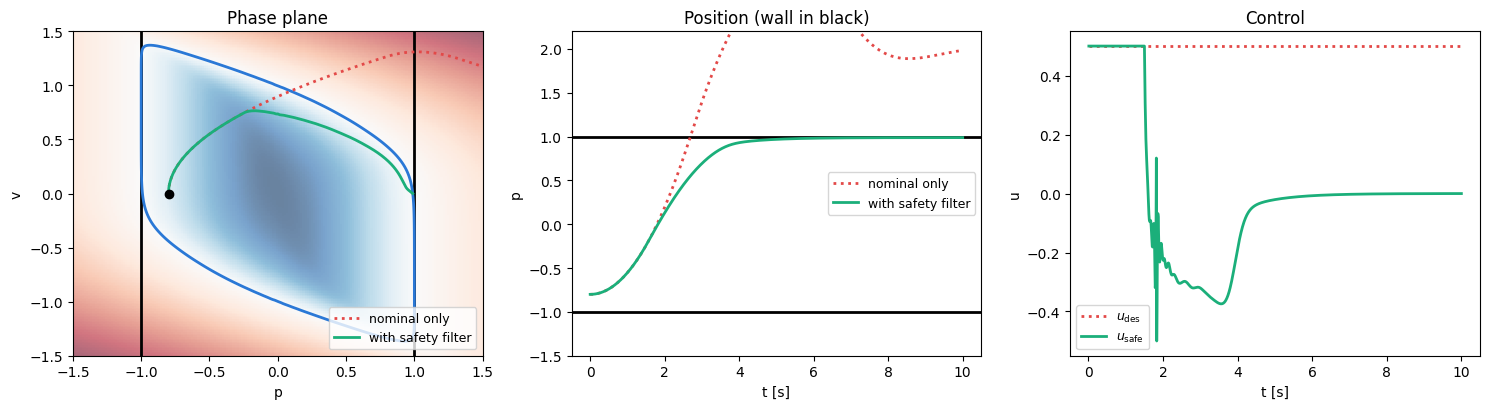

max p with filter: 0.9879   (wall at 1.0)
max p nominal:     2.8851


In [6]:
def cbf_value_and_grad(x: torch.Tensor):
    x = x.detach().requires_grad_(True)
    v = cbf(x)
    return v.detach(), torch.autograd.grad(v.sum(), x)[0].detach()


def safety_filter(x: torch.Tensor, u_des: torch.Tensor, alpha: float = 1.0) -> torch.Tensor:
    # Closed-form CBF-QP for nu == 1: the constraint is just a bound on u.
    v, grad = cbf_value_and_grad(x)
    LfV = torch.bmm(grad.unsqueeze(1), dyn.f(x)).reshape(-1)                        # ∇V·f(x)
    LgV = torch.bmm(grad.unsqueeze(1), dyn.g(x).expand(x.shape[0], -1, -1)).reshape(-1)  # ∇V·g(x)
    u = u_des.reshape(-1).clone()
    bound = -(LfV + alpha * v) / LgV
    push, pull = LgV > 1e-6, LgV < -1e-6
    u[push] = torch.maximum(u[push], bound[push])
    u[pull] = torch.minimum(u[pull], bound[pull])
    return u.clamp(dyn.u_min[0], dyn.u_max[0]).reshape(-1, 1)


def simulate(x0, T, dt, use_filter=True):
    x = torch.as_tensor([x0], dtype=torch.float32, device=device)
    xs, us_des, us = [x], [], []
    for _ in range(int(round(T / dt))):
        u_des = nominal_controller(x)
        u = safety_filter(x, u_des) if use_filter else u_des
        x = dyn.euler_step(x, u, dt)
        xs.append(x); us_des.append(u_des); us.append(u)
    return (torch.cat(xs).cpu().numpy(), torch.cat(us_des).cpu().numpy(), torch.cat(us).cpu().numpy())


def nominal_controller(x: torch.Tensor, p_goal: float = 2.0, kp: float = 2.0, kd: float = 1.5):
    p, v = x[:, 0], x[:, 1]
    return (kp * (p_goal - p) - kd * v).reshape(-1, 1).clamp(dyn.u_min[0], dyn.u_max[0])


x0, DT = (-0.8, 0.0), 0.01
xs_f, ud_f, u_f = simulate(x0, T=10.0, dt=DT, use_filter=True)
xs_n, _, _ = simulate(x0, T=10.0, dt=DT, use_filter=False)
t = np.arange(xs_f.shape[0]) * DT

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
ax = axes[0]
ax.pcolormesh(G[..., 0], G[..., 1], V_grid, cmap=CMAP_V, shading="auto", rasterized=True, alpha=0.6, norm=norm_V)
ax.contour(G[..., 0], G[..., 1], constr_on_grid, levels=[0], colors=C_CONSTRAINT, linewidths=2)
ax.contour(G[..., 0], G[..., 1], V_grid, levels=[0], colors=C_LEARNED, linewidths=2)
ax.plot(xs_n[:, 0], xs_n[:, 1], color=C_UNSAFE, lw=2, ls=":", label="nominal only")
ax.plot(xs_f[:, 0], xs_f[:, 1], color=C_SAFE, lw=2, label="with safety filter")
ax.plot(*x0, "ko", ms=6)
ax.set_xlim(dyn.x_min[0].item(), dyn.x_max[0].item()); ax.set_ylim(dyn.x_min[1].item(), dyn.x_max[1].item())
ax.set_xlabel("p"); ax.set_ylabel("v"); ax.set_title("Phase plane"); ax.legend(loc="lower right", fontsize=9)

ax = axes[1]
ax.axhline(D, color=C_CONSTRAINT, lw=2); ax.axhline(-D, color=C_CONSTRAINT, lw=2)
ax.plot(t, xs_n[:, 0], color=C_UNSAFE, lw=2, ls=":", label="nominal only")
ax.plot(t, xs_f[:, 0], color=C_SAFE, lw=2, label="with safety filter")
ax.set_ylim(-1.5, 2.2); ax.set_xlabel("t [s]"); ax.set_ylabel("p")
ax.set_title("Position (wall in black)"); ax.legend(loc="center right", fontsize=9)

ax = axes[2]
ax.plot(t[1:], ud_f[:, 0], color=C_UNSAFE, lw=2, ls=":", label=r"$u_\mathrm{des}$")
ax.plot(t[1:], u_f[:, 0], color=C_SAFE, lw=2, label=r"$u_\mathrm{safe}$")
ax.set_xlabel("t [s]"); ax.set_ylabel("u"); ax.set_title("Control"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"max p with filter: {xs_f[:, 0].max():.4f}   (wall at {D})")
print(f"max p nominal:     {xs_n[:, 0].max():.4f}")

---

The same run from the CLI: `python scripts/train.py --config configs/double_integrator_1d.yaml`.